# Small Image Classification with MLP

In [1]:
import time

import numpy as np
import matplotlib.pylab as plt
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

device = "cuda"

## Broken Chessboard Classification

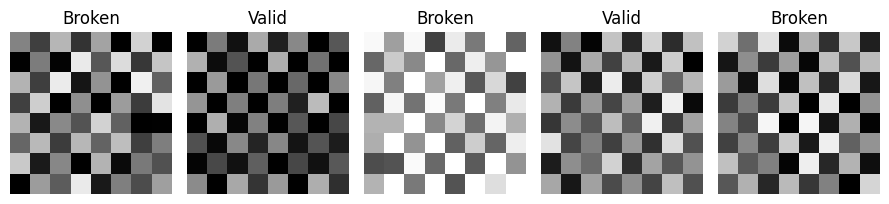

In [2]:
class CheckerboardDataset(Dataset):
    """
    PyTorch dataset generating:
    - Valid noisy checkerboards (label = 1)
    - Broken (phase-shifted) noisy checkerboards (label = 0)

    Noise is applied ONLY to intensities for both classes.
    Broken class may get slight structural corruption.
    """

    def __init__(
        self,
        num_samples=1000,
        size=8,
        noise_white=120,
        noise_black=120,
        bitflip_prob_broken=0.02,   # only for broken
    ):
        super().__init__()
        self.num_samples = num_samples
        self.size = size
        self.noise_white = noise_white
        self.noise_black = noise_black
        self.bitflip_prob_broken = bitflip_prob_broken

        self.images = []
        self.labels = []

        for _ in range(num_samples):

            label = np.random.randint(0, 2)   # FIXED: now 0 or 1


            x = np.indices((size, size))
            img = (x[0] % 2) ^ (x[1] % 2)
            if label == 0:
                img = 1 - img   # broken pattern

            img = img.astype(np.float32)

            if label == 0 and self.bitflip_prob_broken > 0:
                flip_mask = np.random.rand(size, size) < self.bitflip_prob_broken
                img[flip_mask] = 1 - img[flip_mask]

            img_255 = img * 255.0

            # noise for white squares
            white_mask = img == 1
            white_noise = np.random.randint(0, noise_white + 1, img.shape)
            img_255 -= white_noise * white_mask

            # noise for black squares
            black_mask = img == 0
            black_noise = np.random.randint(0, noise_black + 1, img.shape)
            img_255 += black_noise * black_mask

            # offset the whole image
            offset = np.random.randint(5, 100)
            img_255 = img_255 + offset if np.random.choice([True, False]) else img_255 - offset
            
            # final clipping and conversion
            img_255 = np.clip(img_255, 0, 255).astype(np.uint8)

            # ------------------------------
            # 5) Normalize to [0,1] tensor
            # ------------------------------
            img_tensor = torch.tensor(img_255, dtype=torch.float32).unsqueeze(0) / 255.0

            self.images.append(img_tensor)
            self.labels.append(torch.tensor([label], dtype=torch.float32))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]



dataset = CheckerboardDataset(num_samples=200, size=8)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

imgs, labels = next(iter(loader))

plt.figure(figsize=(9, 2))
for i in range(5):
    img = imgs[i].squeeze(0)
    label = int(labels[i].item())

    plt.subplot(1, 5, i + 1)
    img_np = img.squeeze().cpu().numpy().astype(np.float32) * 255
    plt.imshow(img_np, cmap='gray', vmin=0, vmax=255)
    
    plt.title("Valid" if label == 1 else "Broken")
    plt.axis("off")

plt.tight_layout()
fig_name = "classification_chessboard_data"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

In [3]:
class MLP(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

model = MLP()
img = torch.rand((10, 8, 8))
output = model(img)
output.shape

torch.Size([10])

Epoch 0/60 | Train Loss: 0.69397 | Val Loss: 0.68428 | Val Acc: 53.00%
Epoch 10/60 | Train Loss: 0.61068 | Val Loss: 0.59700 | Val Acc: 100.00%
Epoch 20/60 | Train Loss: 0.42343 | Val Loss: 0.40232 | Val Acc: 100.00%
Epoch 30/60 | Train Loss: 0.15231 | Val Loss: 0.14292 | Val Acc: 100.00%
Epoch 40/60 | Train Loss: 0.02423 | Val Loss: 0.02570 | Val Acc: 100.00%
Epoch 50/60 | Train Loss: 0.00433 | Val Loss: 0.00547 | Val Acc: 100.00%


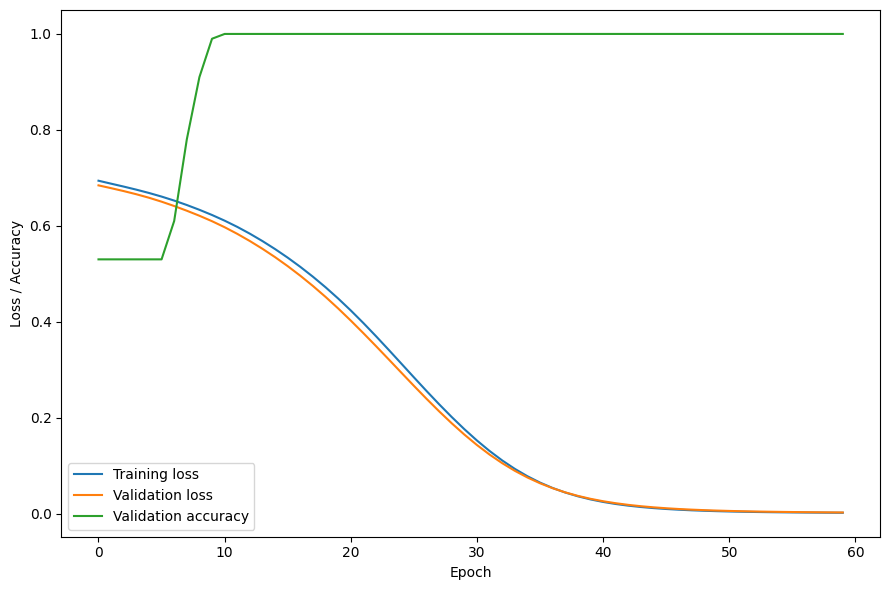

In [4]:
# --------- Dataset ----------
dataset = CheckerboardDataset(num_samples=1100, size=8)

# Split into 10k train, 1k val
train_set, val_set = random_split(dataset, [1000, 100])

train_loader = DataLoader(train_set, batch_size=1000, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=100, shuffle=False)

# --------- Model ----------
model = MLP()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 60
train_losses = np.zeros(epochs)
val_losses = np.zeros(epochs)
val_accs   = np.zeros(epochs)     # <-- NEW

# --------- Training Loop ----------
for epoch in range(epochs):
    model.train()
    batch_losses = []

    for inputs, targets in train_loader:
        targets = targets.squeeze(-1)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_targets = val_targets.squeeze(-1)
            val_outputs = model(val_inputs)

            # Loss
            val_loss = criterion(val_outputs, val_targets).item()

            # ---- Accuracy ----
            preds = (val_outputs > 0.5).float()
            correct = (preds == val_targets).sum().item()
            accuracy = correct / val_targets.numel()

    # Save losses + acc
    train_losses[epoch] = train_loss
    val_losses[epoch]   = val_loss
    val_accs[epoch]     = accuracy

    # Print occasionally
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.5f} | "
              f"Val Loss: {val_loss:.5f} | "
              f"Val Acc: {accuracy*100:.2f}%")

# --------- Plotting ----------
plt.figure(figsize=(9, 6))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.plot(val_accs, label="Validation accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.tight_layout()
# fig_name = "classification_chessboard_results"
# plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
# plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()



## Train and Validation Split

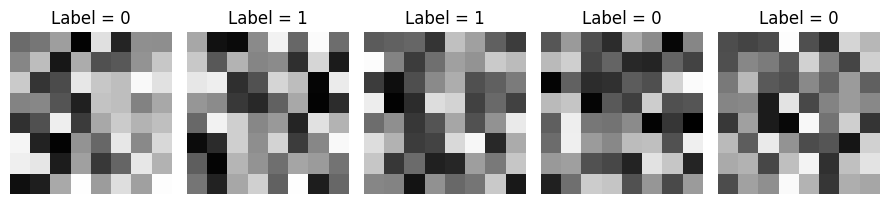

In [5]:
class PixelMaskDataset(Dataset):
    """
    XOR-ish nonlinear task:
      - Fixed gradient mask M
      - score = sum(M * image)
      - Quartiles q1 < q2 < q3 of score distribution
      - Label = 0 in Q1, 1 in Q2+Q3, 0 in Q4
    """

    def __init__(self, num_samples=1000, size=8, quartile_samples=5000):
        super().__init__()
        self.num_samples = num_samples
        self.size = size

        # 1) gradient mask in [0, 1]
        x = np.linspace(0, 1, size)
        y = np.linspace(0, 1, size)
        xx, yy = np.meshgrid(x, y)
        self.mask = (xx + yy) / 2.0

        # 2) estimate quartiles of score distribution
        scores = []
        for _ in range(quartile_samples):
            img = np.random.randint(0, 256, (size, size), dtype=np.uint8)
            score = np.sum(self.mask * img)
            scores.append(score)

        self.q1 = np.quantile(scores, 0.25)
        self.q2 = np.quantile(scores, 0.50)
        self.q3 = np.quantile(scores, 0.75)

        # 3) generate actual dataset
        self.images = []
        self.labels = []

        for _ in range(num_samples):
            img = np.random.randint(0, 256, (size, size), dtype=np.uint8)
            score = np.sum(self.mask * img)

            if score < self.q1:
                label = 0
            elif score < self.q2:
                label = 1
            elif score < self.q3:
                label = 1
            else:
                label = 0

            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
            label_tensor = torch.tensor(label, dtype=torch.float32)  # scalar, not [label]

            self.images.append(img_tensor)
            self.labels.append(label_tensor)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


dataset = PixelMaskDataset(num_samples=200, size=8)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

imgs, labels = next(iter(loader))

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 2))
for i in range(5):
    img = imgs[i].squeeze(0)
    label = int(labels[i].item())

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.numpy(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Label = {label}")
    plt.axis("off")

plt.tight_layout()
fig_name = "classification_pixelsum_data"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

Epoch 0/60 | Train Loss: 0.69371 | Val Loss: 0.69249 | Val Acc: 52.20%
Epoch 1/60 | Train Loss: 0.69305 | Val Loss: 0.69268 | Val Acc: 52.30%
Epoch 2/60 | Train Loss: 0.69274 | Val Loss: 0.69259 | Val Acc: 52.20%
Epoch 3/60 | Train Loss: 0.69254 | Val Loss: 0.69241 | Val Acc: 52.20%
Epoch 4/60 | Train Loss: 0.69226 | Val Loss: 0.69267 | Val Acc: 52.70%
Epoch 5/60 | Train Loss: 0.69198 | Val Loss: 0.69262 | Val Acc: 52.50%
Epoch 6/60 | Train Loss: 0.69138 | Val Loss: 0.69278 | Val Acc: 53.20%
Epoch 7/60 | Train Loss: 0.69081 | Val Loss: 0.69290 | Val Acc: 53.60%
Epoch 8/60 | Train Loss: 0.68952 | Val Loss: 0.69317 | Val Acc: 52.80%
Epoch 9/60 | Train Loss: 0.68869 | Val Loss: 0.69256 | Val Acc: 52.70%
Epoch 10/60 | Train Loss: 0.68607 | Val Loss: 0.69209 | Val Acc: 51.90%
Epoch 11/60 | Train Loss: 0.68236 | Val Loss: 0.69057 | Val Acc: 52.70%
Epoch 12/60 | Train Loss: 0.67720 | Val Loss: 0.68784 | Val Acc: 53.40%
Epoch 13/60 | Train Loss: 0.67057 | Val Loss: 0.68527 | Val Acc: 54.80%
Ep

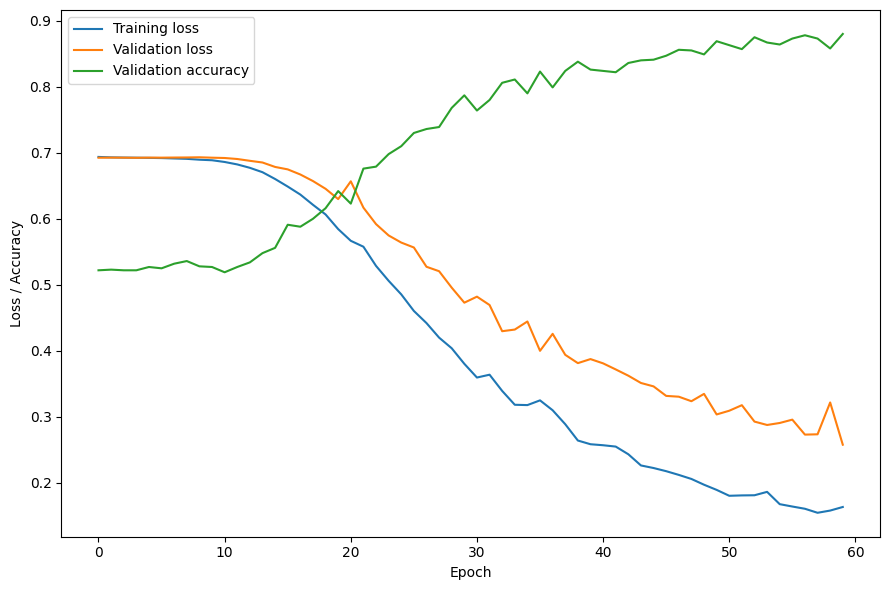

In [6]:
# --------- Dataset ----------
dataset = PixelMaskDataset(num_samples=11000, size=8)

# Split into 10k train, 1k val
train_set, val_set = random_split(dataset, [10000, 1000])

train_loader = DataLoader(train_set, batch_size=1000, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=1000, shuffle=False)

# --------- Model ----------
model = MLP()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 60
train_losses = np.zeros(epochs)
val_losses = np.zeros(epochs)
val_accs   = np.zeros(epochs)     # <-- NEW

# --------- Training Loop ----------
for epoch in range(epochs):
    model.train()
    batch_losses = []

    for inputs, targets in train_loader:
        targets = targets.squeeze(-1)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_targets = val_targets.squeeze(-1)
            val_outputs = model(val_inputs)

            # Loss
            val_loss = criterion(val_outputs, val_targets).item()

            # ---- Accuracy ----
            preds = (val_outputs > 0.5).float()
            correct = (preds == val_targets).sum().item()
            accuracy = correct / val_targets.numel()

    # Save losses + acc
    train_losses[epoch] = train_loss
    val_losses[epoch]   = val_loss
    val_accs[epoch]     = accuracy

    # Print occasionally
    if epoch % 1 == 0:
        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.5f} | "
              f"Val Loss: {val_loss:.5f} | "
              f"Val Acc: {accuracy*100:.2f}%")

# --------- Plotting ----------
plt.figure(figsize=(9, 6))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.plot(val_accs, label="Validation accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.tight_layout()
# fig_name = "classification_pixelsum_results"
# plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
# plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

===== Run 1/50 =====
===== Run 2/50 =====
===== Run 3/50 =====
===== Run 4/50 =====
===== Run 5/50 =====
===== Run 6/50 =====
===== Run 7/50 =====
===== Run 8/50 =====
===== Run 9/50 =====
===== Run 10/50 =====
===== Run 11/50 =====
===== Run 12/50 =====
===== Run 13/50 =====
===== Run 14/50 =====
===== Run 15/50 =====
===== Run 16/50 =====
===== Run 17/50 =====
===== Run 18/50 =====
===== Run 19/50 =====
===== Run 20/50 =====
===== Run 21/50 =====
===== Run 22/50 =====
===== Run 23/50 =====
===== Run 24/50 =====
===== Run 25/50 =====
===== Run 26/50 =====
===== Run 27/50 =====
===== Run 28/50 =====
===== Run 29/50 =====
===== Run 30/50 =====
===== Run 31/50 =====
===== Run 32/50 =====
===== Run 33/50 =====
===== Run 34/50 =====
===== Run 35/50 =====
===== Run 36/50 =====
===== Run 37/50 =====
===== Run 38/50 =====
===== Run 39/50 =====
===== Run 40/50 =====
===== Run 41/50 =====
===== Run 42/50 =====
===== Run 43/50 =====
===== Run 44/50 =====
===== Run 45/50 =====
===== Run 46/50 ===

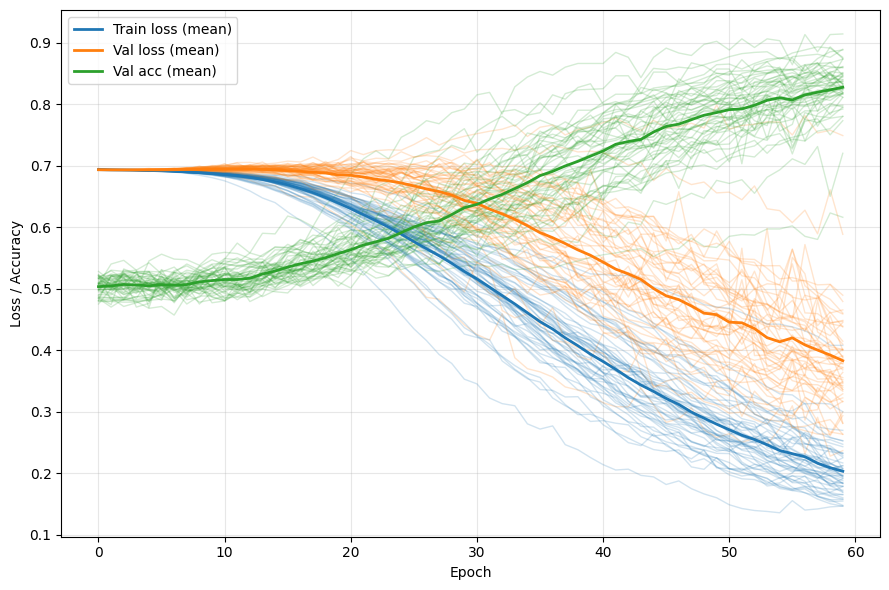

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# --------- Config ----------
num_runs = 50
epochs = 60
batch_size = 1000

# --------- Dataset ----------
dataset = PixelMaskDataset(num_samples=11000, size=8)

# --------- Storage ----------
train_losses_all = np.zeros((num_runs, epochs))
val_losses_all   = np.zeros((num_runs, epochs))
val_accs_all     = np.zeros((num_runs, epochs))

# ============================================================
#                    Simulation loop
# ============================================================
for run in range(num_runs):

    print(f"===== Run {run+1}/{num_runs} =====")

    # ---- Random split every run ----
    train_set, val_set = random_split(dataset, [10000, 1000])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)

    # ---- Model ----
    model = MLP()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # --------- Training Loop ----------
    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for inputs, targets in train_loader:
            targets = targets.squeeze(-1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            for val_inputs, val_targets in val_loader:
                val_targets = val_targets.squeeze(-1)
                val_outputs = model(val_inputs)

                val_loss = criterion(val_outputs, val_targets).item()

                preds = (val_outputs > 0.5).float()
                correct = (preds == val_targets).sum().item()
                accuracy = correct / val_targets.numel()

        # ---- Store ----
        train_losses_all[run, epoch] = train_loss
        val_losses_all[run, epoch]   = val_loss
        val_accs_all[run, epoch]     = accuracy

# ============================================================
#                         Plotting
# ============================================================
epochs_range = np.arange(epochs)

plt.figure(figsize=(9, 6))

# ---- Individual runs (thin) ----
for i in range(num_runs):
    plt.plot(epochs_range, train_losses_all[i], color="tab:blue",  alpha=0.2, linewidth=1)
    plt.plot(epochs_range, val_losses_all[i],   color="tab:orange", alpha=0.2, linewidth=1)
    plt.plot(epochs_range, val_accs_all[i],     color="tab:green",  alpha=0.2, linewidth=1)

# ---- Mean curves (thick) ----
plt.plot(epochs_range, train_losses_all.mean(axis=0),
         color="tab:blue", linewidth=2, label="Train loss (mean)")

plt.plot(epochs_range, val_losses_all.mean(axis=0),
         color="tab:orange", linewidth=2, label="Val loss (mean)")

plt.plot(epochs_range, val_accs_all.mean(axis=0),
         color="tab:green", linewidth=2, label="Val acc (mean)")

plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
fig_name = "classification_pixelsum_results_manyruns"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

## Trainining, Validation and Testing

Epoch 0/60 | Train Loss: 0.69325 | Val Acc: 49.20% | Test Acc: 51.20%
Epoch 1/60 | Train Loss: 0.69315 | Val Acc: 50.80% | Test Acc: 51.40%
Epoch 2/60 | Train Loss: 0.69264 | Val Acc: 49.80% | Test Acc: 48.50%
Epoch 3/60 | Train Loss: 0.69245 | Val Acc: 48.90% | Test Acc: 48.90%
Epoch 4/60 | Train Loss: 0.69210 | Val Acc: 51.10% | Test Acc: 49.60%
Epoch 5/60 | Train Loss: 0.69154 | Val Acc: 50.40% | Test Acc: 48.90%
Epoch 6/60 | Train Loss: 0.69102 | Val Acc: 50.70% | Test Acc: 48.00%
Epoch 7/60 | Train Loss: 0.68982 | Val Acc: 51.30% | Test Acc: 52.30%
Epoch 8/60 | Train Loss: 0.68920 | Val Acc: 49.80% | Test Acc: 52.60%
Epoch 9/60 | Train Loss: 0.68724 | Val Acc: 50.40% | Test Acc: 48.60%
Epoch 10/60 | Train Loss: 0.68541 | Val Acc: 51.90% | Test Acc: 50.50%
Epoch 11/60 | Train Loss: 0.68193 | Val Acc: 52.70% | Test Acc: 51.70%
Epoch 12/60 | Train Loss: 0.67869 | Val Acc: 52.30% | Test Acc: 53.20%
Epoch 13/60 | Train Loss: 0.67643 | Val Acc: 53.60% | Test Acc: 52.60%
Epoch 14/60 | Tr

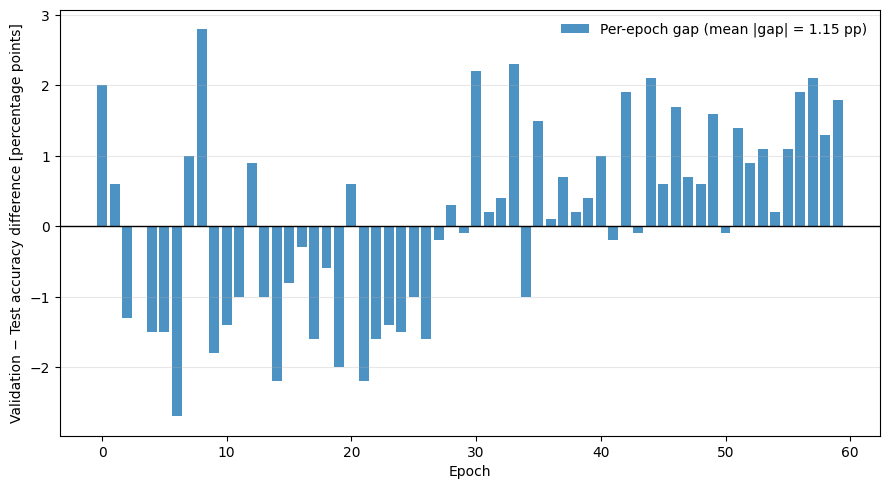

In [10]:
# --------- Dataset ----------
dataset = PixelMaskDataset(num_samples=11000, size=8)

# Split: 9k train, 1k val, 1k test
train_set, val_set, test_set = random_split(dataset, [9000, 1000, 1000])

train_loader = DataLoader(train_set, batch_size=1000, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=1000, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=1000, shuffle=False)

# --------- Model ----------
model = MLP()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 60
train_losses = np.zeros(epochs)
val_losses   = np.zeros(epochs)
val_accs     = np.zeros(epochs)
test_accs    = np.zeros(epochs)   # <-- NEW

# ============================================================
#                     Training Loop
# ============================================================
for epoch in range(epochs):
    model.train()
    batch_losses = []

    for inputs, targets in train_loader:
        targets = targets.squeeze(-1)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ---------------- Validation ----------------
    model.eval()
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_targets = val_targets.squeeze(-1)
            val_outputs = model(val_inputs)

            val_loss = criterion(val_outputs, val_targets).item()

            preds = (val_outputs > 0.5).float()
            correct = (preds == val_targets).sum().item()
            val_accuracy = correct / val_targets.numel()

    # ---------------- Test ----------------
    with torch.no_grad():
        for test_inputs, test_targets in test_loader:
            test_targets = test_targets.squeeze(-1)
            test_outputs = model(test_inputs)

            preds = (test_outputs > 0.5).float()
            correct = (preds == test_targets).sum().item()
            test_accuracy = correct / test_targets.numel()

    # ---- Save ----
    train_losses[epoch] = train_loss
    val_losses[epoch]   = val_loss
    val_accs[epoch]     = val_accuracy
    test_accs[epoch]    = test_accuracy

    print(
        f"Epoch {epoch}/{epochs} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Acc: {val_accuracy*100:.2f}% | "
        f"Test Acc: {test_accuracy*100:.2f}%"
    )

# ============================================================
#                 Plotting: Val–Test gap
# ============================================================
acc_gap = test_accs - val_accs
mean_abs_gap = np.mean(np.abs(acc_gap)) * 100  # percentage points

plt.figure(figsize=(9, 5))

plt.bar(
    np.arange(epochs),
    acc_gap * 100,
    width=0.8,
    alpha=0.8,
    label=f"Per-epoch gap (mean |gap| = {mean_abs_gap:.2f} pp)"
)

plt.axhline(
    0.0,
    color="black",
    linewidth=1,
)

plt.xlabel("Epoch")
plt.ylabel("Validation − Test accuracy difference [percentage points]")
plt.grid(axis="y", alpha=0.3)

plt.legend(frameon=False)
plt.tight_layout()
fig_name = "classification_pixelsum_test_val_gap"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

## Overfiting and Size of the Sample


=== Training with 1000 samples for 500 epochs ===
[1000] Epoch    0/500 | Train Loss: 0.69323 | Val Loss: 0.69315 | Val Acc: 49.90%
[1000] Epoch   50/500 | Train Loss: 0.59146 | Val Loss: 0.75313 | Val Acc: 51.70%
[1000] Epoch  100/500 | Train Loss: 0.25839 | Val Loss: 1.05070 | Val Acc: 51.90%
[1000] Epoch  150/500 | Train Loss: 0.08041 | Val Loss: 1.60899 | Val Acc: 50.20%
[1000] Epoch  200/500 | Train Loss: 0.01607 | Val Loss: 2.24975 | Val Acc: 49.80%
[1000] Epoch  250/500 | Train Loss: 0.00501 | Val Loss: 2.71448 | Val Acc: 50.20%
[1000] Epoch  300/500 | Train Loss: 0.00237 | Val Loss: 3.01178 | Val Acc: 50.20%
[1000] Epoch  350/500 | Train Loss: 0.00129 | Val Loss: 3.27295 | Val Acc: 50.30%
[1000] Epoch  400/500 | Train Loss: 0.00080 | Val Loss: 3.48027 | Val Acc: 50.30%
[1000] Epoch  450/500 | Train Loss: 0.00054 | Val Loss: 3.73209 | Val Acc: 50.20%

=== Training with 10000 samples for 50 epochs ===
[10000] Epoch    0/50 | Train Loss: 0.69353 | Val Loss: 0.69341 | Val Acc: 49.

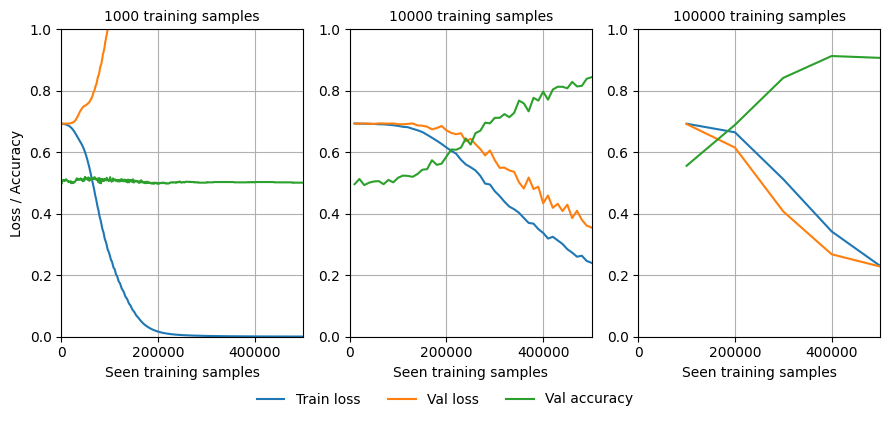

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ============================================================
#                       SETTINGS
# ============================================================
train_sizes = [1_000, 10_000, 100_000]
val_size = 1_000
batch_size = 1_000

# Reference scaling: 10k samples -> 60 epochs
ref_train_size = 10_000
ref_epochs = 50

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
#                       PLOTTING SETUP
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True)

# ============================================================
#                    EXPERIMENT LOOP
# ============================================================
for ax, train_size in zip(axes, train_sizes):

    # ---- Epochs proportional to training size ----
    epochs = int(ref_epochs * ref_train_size / train_size)

    print(f"\n=== Training with {train_size} samples for {epochs} epochs ===")

    # ---- Dataset (exact size per experiment) ----
    dataset = PixelMaskDataset(
        num_samples=train_size + val_size,
        size=8
    )

    train_set, val_set = random_split(
        dataset, [train_size, val_size]
    )

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size, shuffle=False
    )

    # ---- Model ----
    model = MLP()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ---- Logs ----
    train_losses = np.zeros(epochs)
    val_losses   = np.zeros(epochs)
    val_accs     = np.zeros(epochs)

    # ========================================================
    #                      TRAINING LOOP
    # ========================================================
    for epoch in range(epochs):

        # ---------- Training ----------
        model.train()
        batch_losses = []

        for inputs, targets in train_loader:
            targets = targets.squeeze(-1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        # ---------- Validation ----------
        model.eval()
        with torch.no_grad():
            for val_inputs, val_targets in val_loader:
                val_targets = val_targets.squeeze(-1)
                val_outputs = model(val_inputs)

                val_loss = criterion(val_outputs, val_targets).item()

                preds = (val_outputs > 0.5).float()
                correct = (preds == val_targets).sum().item()
                accuracy = correct / val_targets.numel()

        # ---------- Store logs ----------
        train_losses[epoch] = train_loss
        val_losses[epoch]   = val_loss
        val_accs[epoch]     = accuracy

        if epoch % max(1, epochs // 10) == 0:
            print(
                f"[{train_size}] "
                f"Epoch {epoch:4d}/{epochs} | "
                f"Train Loss: {train_loss:.5f} | "
                f"Val Loss: {val_loss:.5f} | "
                f"Val Acc: {accuracy*100:.2f}%"
            )

    # ========================================================
    #                        PLOTTING
    # ========================================================
    x = np.arange(1, epochs + 1) * train_size  # same scale, different granularity

    ax.plot(x, train_losses, label="Train loss")
    ax.plot(x, val_losses,   label="Val loss")
    ax.plot(x, val_accs,     label="Val accuracy")

    ax.set_title(f"{train_size} training samples", fontsize=plt.rcParams["legend.fontsize"])
    ax.set_xlabel("Seen training samples")
    ax.grid(True)

axes[0].set_ylabel("Loss / Accuracy")


from matplotlib.ticker import MaxNLocator
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(0.0, 500000)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.06)
)


plt.tight_layout()
fig_name = "classification_pixelsum_results"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()